# Nhiệm vụ 7: Đánh giá Chất lượng Phân cụm (PCA + K-Means)
Notebook này thực hiện việc đánh giá chất lượng cụm của mô hình **PCA + K-Means (Global K=2)** qua 15 tháng development theo đúng chuẩn cấu trúc dự án.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

# Thiết lập thư mục làm việc về gốc repository
current_dir = os.getcwd()
if 'm2-clustering-experiment' not in current_dir:
    # Kernel có thể đang chạy ở Desktop/M2/
    if os.path.exists('Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment'):
        os.chdir('Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment')
else:
    while not os.getcwd().endswith('m2-clustering-experiment'):
        os.chdir('..')

# Nạp dữ liệu từ Task 6
input_path = 'M2/artifacts/m2-task6-pca-kmeans-v1/diagnostics.csv'
df = pd.read_csv(input_path)

# Lọc chuẩn hóa chỉ lấy Global K = 2
df_k2 = df[df['k'] == 2].copy()
df_k2['snapshot_date'] = pd.to_datetime(df_k2['snapshot_date']).dt.strftime('%Y-%m-%d')
df_k2 = df_k2.sort_values('snapshot_date').reset_index(drop=True)
print(f"Đã nạp {len(df_k2)} snapshots cho K=2.")


Đã nạp 15 snapshots cho K=2.


## 1. Phân cấp ưu tiên tiêu chí theo Kế hoạch Dự án
- **Tiêu chí cấp 1 (Primary Criterion):** Median Silhouette cao nhất. Đây là cơ sở toán học cao nhất để chứng minh K=2 tạo ra ranh giới tách biệt rõ ràng nhất giữa các nhóm cổ phiếu trên thị trường Việt Nam.
- **Tiêu chí phụ và thế cân bằng (Secondary Tie-breaker):** Median Davies-Bouldin thấp hơn. Dùng khi Silhouette giữa các phương án xấp xỉ nhau.
- **Tiêu chí kiểm định an toàn (Sanity Diagnostics):** Calinski-Harabasz và Cluster Balance dùng để kiểm tra độ tin cậy, cảnh báo nguy cơ phân cụm bị chi phối bởi các cổ phiếu dị biệt.

In [6]:
## BẢNG 1: TÓM TẮT THỐNG KÊ CHẤT LƯỢNG K=2
metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz', 'inertia', 'cluster_balance']
summary_data = []

for m in metrics:
    summary_data.append({
        'metric': m,
        'n_total': 15,
        'n_available': df_k2[m].notna().sum(),
        'mean': df_k2[m].mean(),
        'median': df_k2[m].median(),
        'minimum': df_k2[m].min(),
        'maximum': df_k2[m].max()
    })

df_summary = pd.DataFrame(summary_data)
print("BẢNG 1: TÓM TẮT THỐNG KÊ CHẤT LƯỢNG (K=2)")
display(df_summary)

BẢNG 1: TÓM TẮT THỐNG KÊ CHẤT LƯỢNG (K=2)


,metric,n_total,n_available,mean,median,minimum,maximum
0,silhouette,15,15,0.804410,0.771666,0.659505,0.951234
1,davies_bouldin,15,15,0.499010,0.515502,0.354967,0.716695
2,calinski_harabasz,15,15,709.194537,361.527940,176.314178,2065.151594
3,inertia,15,15,53212.333977,1963.065124,1219.015572,328111.440073
4,cluster_balance,15,15,0.056407,0.067669,0.010363,0.094972


In [7]:
## BẢNG 2: CHI TIẾT CHẤT LƯỢNG QUA 15 SNAPSHOTS (K=2)
df_details = df_k2[['snapshot_date', 'silhouette', 'davies_bouldin', 'calinski_harabasz', 'inertia', 'cluster_balance']].copy()
df_details.columns = ['Snapshot', 'Silhouette', 'DB', 'CH', 'Inertia', 'Balance']
print("BẢNG 2: CHI TIẾT QUA 15 THÁNG (K=2)")
display(df_details)

BẢNG 2: CHI TIẾT QUA 15 THÁNG (K=2)


,Snapshot,Silhouette,DB,CH,Inertia,Balance
0,2023-11-30,0.775353,0.536114,225.635234,1219.015572,0.067669
1,2023-12-29,0.771666,0.472406,417.106858,1267.010612,0.089385
2,2024-01-31,0.719430,0.558519,261.530664,1360.147611,0.094972
3,2024-02-29,0.745119,0.482618,361.527940,1295.238398,0.094972
4,2024-03-29,0.676387,0.590633,190.663829,1257.003284,0.082418
5,2024-04-26,0.728588,0.547559,261.893710,1535.166794,0.070000
6,2024-05-31,0.704280,0.573273,232.343692,1543.374428,0.072816
7,2024-06-28,0.763995,0.515502,274.715119,1963.065124,0.048035
8,2024-07-31,0.659505,0.716695,176.314178,2009.521186,0.073913
9,2024-08-30,0.906888,0.472977,926.687158,121106.779768,0.036585


## 2. Hiện tượng kinh tế và cấu trúc vi mô thị trường
**Giải thích hiện tượng Balance thấp (Fragmentation / Outlier Clusters):**
Nếu Cluster Balance ở mức thấp (< 0.05 hoặc cụm nhỏ chỉ có vài mã đến vài chục mã), điều này phản ánh bản chất thực tế của thị trường: Thuật toán đang tách thị trường thành một nhóm đại trà (phần lớn thị trường) và một nhóm cực đoan (gồm các cổ phiếu siêu động lượng, siêu thanh khoản hoặc biến động dị biệt). Đây là đặc tính tự nhiên của dữ liệu tài chính có đuôi dài (heavy tails), không phải là lỗi thuật toán.

**Phân tích hiện tượng biến động (Spikes):**
Các tháng có điểm chất lượng biến động mạnh phản ánh sự phân hóa hoặc hội tụ của dòng tiền tại thời điểm đó (ví dụ: các nhịp rũ bỏ hoặc bùng nổ của VnIndex).

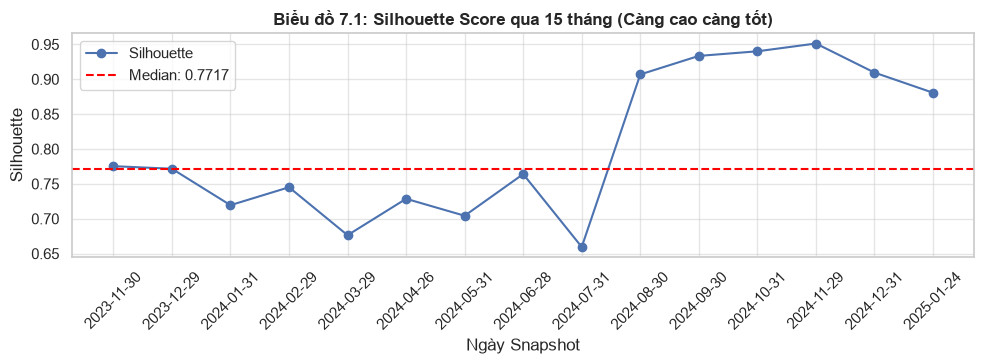

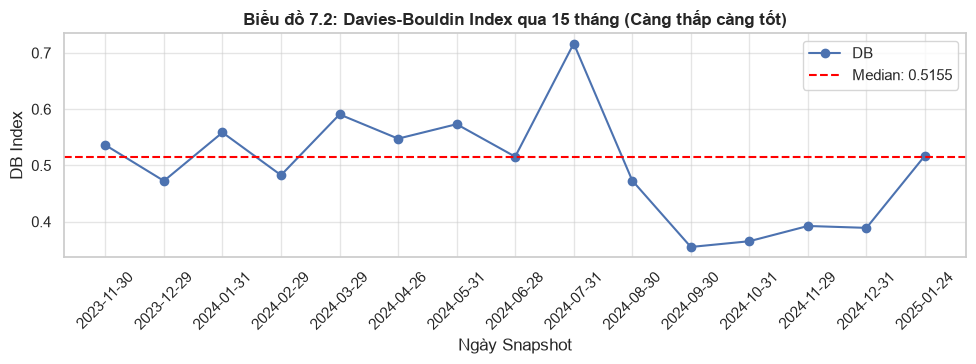

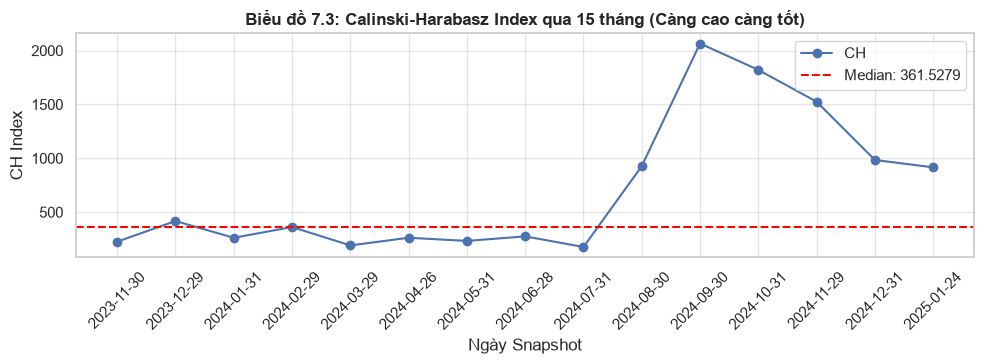

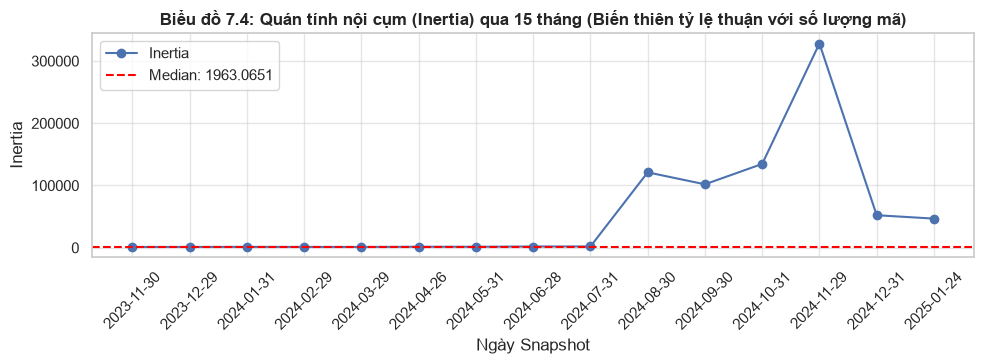

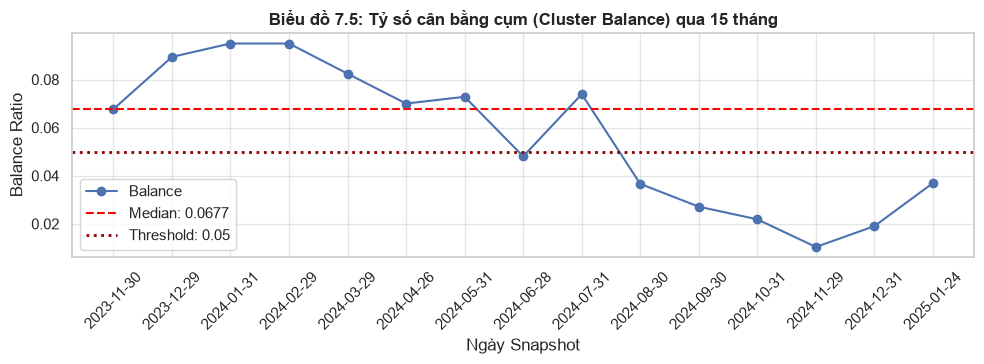

In [8]:
## 3. TRỰC QUAN HÓA (VISUALIZATION CONTRACT)
sns.set_theme(style="whitegrid")

def plot_metric(df, y_col, title, ylabel, plot_num, threshold=None):
    plt.figure(figsize=(10, 3.8))
    plt.plot(df['Snapshot'], df[y_col], marker='o', color='b', label=y_col)
    
    # Đường trung vị màu đỏ đứt nét
    med_val = df[y_col].median()
    plt.axhline(med_val, color='red', linestyle='--', label=f'Median: {med_val:.4f}')
    
    if threshold is not None:
        plt.axhline(threshold, color='darkred', linestyle=':', linewidth=2, label=f'Threshold: {threshold}')
        
    plt.title(f"Biểu đồ {plot_num}: {title}", fontsize=12, fontweight='bold')
    plt.xlabel("Ngày Snapshot")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 7.1 Silhouette
plot_metric(df_details, 'Silhouette', 'Silhouette Score qua 15 tháng (Càng cao càng tốt)', 'Silhouette', '7.1')

# 7.2 DB
plot_metric(df_details, 'DB', 'Davies-Bouldin Index qua 15 tháng (Càng thấp càng tốt)', 'DB Index', '7.2')

# 7.3 CH
plot_metric(df_details, 'CH', 'Calinski-Harabasz Index qua 15 tháng (Càng cao càng tốt)', 'CH Index', '7.3')

# 7.4 Inertia
plot_metric(df_details, 'Inertia', 'Quán tính nội cụm (Inertia) qua 15 tháng (Biến thiên tỷ lệ thuận với số lượng mã)', 'Inertia', '7.4')

# 7.5 Balance
plot_metric(df_details, 'Balance', 'Tỷ số cân bằng cụm (Cluster Balance) qua 15 tháng', 'Balance Ratio', '7.5', threshold=0.05)


## 3. Ranh giới kỷ luật phương pháp luận (Methodology Boundaries)
- **Cảnh báo về Inertia trên chuỗi thời gian:** Tuyệt đối không so sánh giá trị Inertia tuyệt đối giữa các tháng với nhau vì quy mô mã N tăng từ 142 lên 780 làm Inertia tăng cơ học. Inertia chỉ có giá trị khi so sánh các K khác nhau trong cùng 1 tháng.
- **Nghiêm cấm tối ưu hóa bằng lợi nhuận:** Không được đưa Return, Sharpe hay ROI vào Nhiệm vụ 7 để chọn mô hình có chất lượng "tốt hơn". Đánh giá chất lượng cụm độc lập hoàn toàn với bài toán danh mục.

In [9]:
# Lưu kết quả chuẩn hóa
out_dir = 'M2/artifacts/m2-evaluation-pca-kmeans'
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, 'quality_summary.csv')
df_summary.to_csv(out_path, index=False)
print(f"Đã lưu Bảng tổng hợp chất lượng vào: {out_path}")

Đã lưu Bảng tổng hợp chất lượng vào: M2/artifacts/m2-evaluation-pca-kmeans\quality_summary.csv
